(569, 30)
(569,)
(455, 30)
(114, 30)


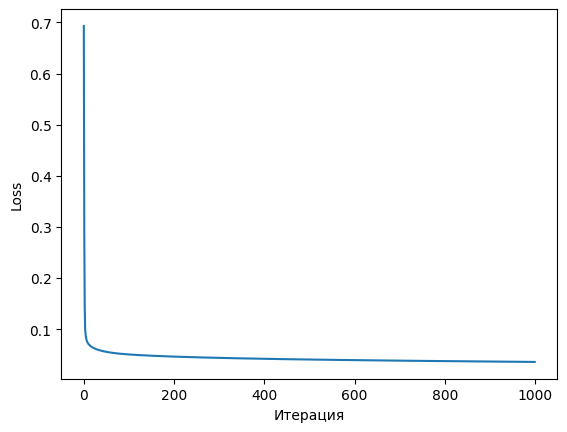

0.9736842105263158
0.9857142857142858
0.971830985915493
0.9787234042553191
sdfsdf
0.9736842105263158
0.9722222222222222
0.9859154929577465
0.9790209790209791


In [ ]:
from sklearn.datasets import load_breast_cancer
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

data = load_breast_cancer()

X = data.data
y = data.target

print(X.shape)
print(y.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

weights = np.zeros(X_train_scaled.shape[1])
bias = 0

def sigmoid(z):
  return 1 / (1 + np.exp(-z))

z = np.dot(X_train_scaled, weights) + bias
predictions = sigmoid(z)

loss = -np.mean(y_train * np.log(predictions) + (1 - y_train) * np.log(1 - predictions))

diff = predictions - y_train

n = X_train_scaled.shape[0]
grad_weights = (2/n) * np.dot(X_train_scaled.T, diff)
grad_bias = (2/n) * diff.sum()

learning_rate = 0.1
new_weights = weights - learning_rate * grad_weights
new_bias = bias - learning_rate * grad_bias

loss_history = []

n_iterations = 1000

weights = np.zeros(X_test_scaled.shape[1])
bias = 0

for i in range(n_iterations):
  z = np.dot(X_train_scaled, weights) + bias
  predictions = sigmoid(z)
  loss = -np.mean(y_train * np.log(predictions) + (1 - y_train) * np.log(1 - predictions))
  diff = predictions - y_train
  n = X_train_scaled.shape[0]
  grad_weights = (2/n) * np.dot(X_train_scaled.T, diff)
  grad_bias = (2/n) * diff.sum()
  learning_rate = 0.1
  weights = weights - learning_rate * grad_weights
  bias = bias - learning_rate * grad_bias
  loss_history.append(loss)

plt.plot(loss_history)
plt.xlabel('Итерация')
plt.ylabel('Loss')
plt.show()


z_test = np.dot(X_test_scaled, weights) + bias
predictions_test = sigmoid(z_test)

predictions_class = (predictions_test > 0.5).astype(int)

print(accuracy_score(y_test, predictions_class))
print(precision_score(y_test, predictions_class))
print(recall_score(y_test, predictions_class))
print(f1_score(y_test, predictions_class))

model = LogisticRegression()
model.fit(X_train_scaled, y_train)

predictions_sklearn = model.predict(X_test_scaled)
print('sdfsdf')
print(accuracy_score(y_test, predictions_sklearn))
print(precision_score(y_test, predictions_sklearn))
print(recall_score(y_test, predictions_sklearn))
print(f1_score(y_test, predictions_sklearn))
